In [1]:
import numpy as np

In [2]:
def load_mnist_images(path):    #加载图像
    with open(path, 'rb') as f:
        magic, num, rows, cols = np.frombuffer(f.read(16), dtype='>i4')
        images = np.frombuffer(f.read(), dtype = np.uint8)
        images = images.reshape(num, rows, cols)
    return images

In [3]:
def load_mnist_labels(path):      #加载标签
    with open(path, 'rb') as f:
        magic, num = np.frombuffer(f.read(8), dtype = '>i4')
        labels = np.frombuffer(f.read(), dtype = np.uint8)
    return labels

In [5]:
!ls -l /kaggle/input/fashionmnist
!ls -l /kaggle/input/fashionmnist/t10k-images-idx3-ubyte

total 205264
-rw-r--r-- 1 nobody nogroup  22176691 Sep 14 15:51 fashion-mnist_test.csv
-rw-r--r-- 1 nobody nogroup 133047193 Sep 14 15:51 fashion-mnist_train.csv
-rw-r--r-- 1 nobody nogroup   7840016 Sep 14 15:51 t10k-images-idx3-ubyte
-rw-r--r-- 1 nobody nogroup     10008 Sep 14 15:51 t10k-labels-idx1-ubyte
-rw-r--r-- 1 nobody nogroup  47040016 Sep 14 15:51 train-images-idx3-ubyte
-rw-r--r-- 1 nobody nogroup     60008 Sep 14 15:51 train-labels-idx1-ubyte
-rw-r--r-- 1 nobody nogroup 7840016 Sep 14 15:51 /kaggle/input/fashionmnist/t10k-images-idx3-ubyte


In [4]:
DATA_ROOT = "kaggle/input"

train_images = load_mnist_images(f"{DATA_ROOT}/train-images-idx3-ubyte")
train_labels = load_mnist_labels(f"{DATA_ROOT}/train-labels-idx1-ubyte")

print(train_images.shape)
print(train_labels.shape)

(60000, 28, 28)
(60000,)


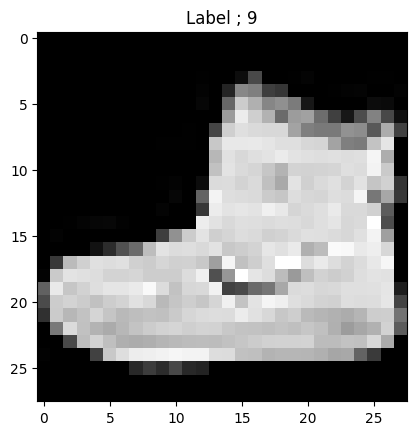

In [5]:
import matplotlib.pyplot as plt
plt.imshow(train_images[0],cmap = 'gray')
plt.title(f"Label ; {train_labels[0]}")
plt.show()

In [6]:
import random
def sample_mnist():
    idx = random.randint(0, len(train_images) - 1)
    return train_images[idx], int(train_labels[idx])

In [7]:
import cv2

IMG_SIZE = 128

def generate_sample(numdigits=2):
    canvas = np.zeros((IMG_SIZE, IMG_SIZE), dtype = np.uint8)
    labels = []

    for _ in range(numdigits):
        img, cls = sample_mnist()
        h, w = img.shape

        x = random.randint(0, IMG_SIZE - w)
        y = random.randint(0, IMG_SIZE - h)
        
        canvas[y:y+h, x:x+w] = img

        cx = (x + w / 2) / IMG_SIZE
        cy = (y + h / 2) / IMG_SIZE
        bw = w / IMG_SIZE
        bh = h / IMG_SIZE

        labels.append(f"{cls} {cx} {cy} {bw} {bh}")
    return canvas, labels

In [8]:
import os
SAVE_IMG = "mnist_det/images/train"
SAVE_LBL = "mnist_det/labels/train"

os.makedirs(SAVE_IMG, exist_ok = True)
os.makedirs(SAVE_LBL, exist_ok = True)

In [9]:
for i in range(2000):
    img, lbls = generate_sample(random.randint(1,3))
    cv2.imwrite(f"{SAVE_IMG}/{i}.jpg", img)
    with open(f"{SAVE_LBL}/{i}.txt", "w") as f:
        f.write("\n".join(lbls))

In [13]:
!ls -R mnist_det | head -n 50

mnist_det:
images
labels

mnist_det/images:
train

mnist_det/images/train:
0.jpg
1000.jpg
1001.jpg
1002.jpg
1003.jpg
1004.jpg
1005.jpg
1006.jpg
1007.jpg
1008.jpg
1009.jpg
100.jpg
1010.jpg
1011.jpg
1012.jpg
1013.jpg
1014.jpg
1015.jpg
1016.jpg
1017.jpg
1018.jpg
1019.jpg
101.jpg
1020.jpg
1021.jpg
1022.jpg
1023.jpg
1024.jpg
1025.jpg
1026.jpg
1027.jpg
1028.jpg
1029.jpg
102.jpg
1030.jpg
1031.jpg
1032.jpg
1033.jpg
1034.jpg
1035.jpg
1036.jpg
1037.jpg
ls: write error: Broken pipe


In [10]:
import os
import shutil
from sklearn.model_selection import train_test_split


base_dir = "/home/rex/fashion-mnist/yolo_file/mnist_det"
img_dir = os.path.join(base_dir, "images/train")
label_dir = os.path.join(base_dir, "labels/train")

val_img_dir = os.path.join(base_dir, "images/val")
val_label_dir = os.path.join(base_dir, "labels/val")
os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_label_dir, exist_ok=True)

all_imgs = [f for f in os.listdir(img_dir) if f.endswith(".jpg")]

train_imgs, val_imgs = train_test_split(all_imgs, test_size=0.2, random_state=42)

for img in val_imgs:
    shutil.move(os.path.join(img_dir, img), os.path.join(val_img_dir, img))

    label_file = img.replace(".jpg", ".txt")
    if os.path.exists(os.path.join(label_dir, label_file)):
        shutil.move(os.path.join(label_dir, label_file), os.path.join(val_label_dir, label_file))
    else:

        with open(os.path.join(val_label_dir, label_file), "w") as f:
            f.write("0 0.5 0.5 1 1\n")

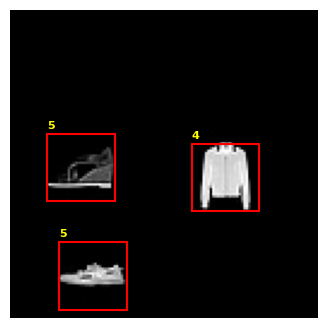

In [11]:
img = cv2.imread('mnist_det/images/train/36.jpg', cv2.IMREAD_GRAYSCALE)

with open("mnist_det/labels/train/36.txt") as f:
    lines = f.readlines()

fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(img, cmap="gray")

for line in lines:
    cls, cx, cy, w, h = map(float, line.split())
    x = (cx - w / 2) * img.shape[1]
    y = (cy - h / 2) * img.shape[0]
    w_px = w * img.shape[1]
    h_px = h * img.shape[0]
    ax.add_patch(
        plt.Rectangle((x, y), w_px, h_px, fill = False, edgecolor='red', linewidth = 1.5)
    )
    ax.text(x, y-2, str(int(cls)), color='yellow', fontsize = 8, weight = 'bold')

ax.axis("off")
plt.show()

In [12]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/home/rex/fashion-mnist/yolo_file/mnist.yaml",
    epochs=20,
    imgsz=128,
    batch=32,
    save_period=5
)



New https://pypi.org/project/ultralytics/8.4.6 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.241 🚀 Python-3.13.9 torch-2.9.1+cu128 CPU (AMD Ryzen 9 8945HX with Radeon Graphics)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/rex/fashion-mnist/yolo_file/mnist.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train6

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7327cd067070>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0


image 1/1 /home/rex/fashion-mnist/yolo_file/mnist_det/images/val/51.jpg: 128x128 1 class_3, 6.5ms
Speed: 0.2ms preprocess, 6.5ms inference, 0.5ms postprocess per image at shape (1, 3, 128, 128)


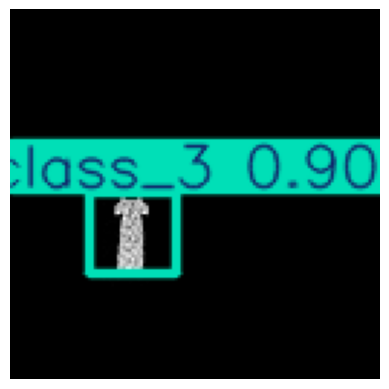

In [20]:
import cv2
import matplotlib.pyplot as plt

trained_model = YOLO("/home/rex/fashion-mnist/yolo_file/runs/detect/train6/weights/best.pt")

test_img_path = "/home/rex/fashion-mnist/yolo_file/mnist_det/images/val/51.jpg"

results = trained_model.predict(test_img_path, imgsz=128)

res = results[0]

res.show()

%matplotlib inline
plt.imshow(cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [18]:
from ultralytics import YOLO
import os

# 加载YOLO模型
def load_model(model_path):
    return YOLO(model_path)

# 获取val目录下的所有图像
def get_val_images(val_dir):
    return [os.path.join(val_dir, file) for file in os.listdir(val_dir) if file.endswith('.jpg')]

# 对单个图像进行推理
def detect_image(model, image_path, save_results=False):
    results = model.predict(
        source=image_path,
        data='mnist.yaml',
        save=save_results,
        show=False,
        verbose=False
    )
    
    detections = []
    for result in results:
        for box in result.boxes:
            detections.append({
                'class': int(box.cls[0]),
                'confidence': float(box.conf[0])
            })
    
    return detections

# 主函数
def main():
    # 配置参数
    MODEL_PATH = '/home/rex/fashion-mnist/yolo_file/runs/detect/train6/weights/best.pt'
    VAL_DIR = '/home/rex/fashion-mnist/yolo_file/mnist_det/images/val'
    SAVE_RESULTS = False

    
    # 加载模型
    model = load_model(MODEL_PATH)
    
    # 获取val图像列表
    val_images = get_val_images(VAL_DIR)
    
    # 遍历所有图像进行检测
    for image_path in val_images:
        detections = detect_image(model, image_path, SAVE_RESULTS)
        
        # 输出结果
        image_name = os.path.basename(image_path)
        print(f"\n{image_name}")
        for det in detections:
            print(f"{det['class']} {det['confidence']:.4f}")

if __name__ == "__main__":
    main()




1875.jpg
3 0.7053

81.jpg
1 0.9526
6 0.4988

1968.jpg
8 0.9535
9 0.9046

574.jpg
9 0.8876
7 0.6793
6 0.3245

1558.jpg
1 0.8914
9 0.7910

54.jpg
1 0.9458
0 0.3662
8 0.3086

677.jpg
2 0.8976

35.jpg
9 0.7951

1581.jpg
7 0.5298

1014.jpg
9 0.9289

1393.jpg
9 0.9533

1748.jpg
6 0.5139

1941.jpg
7 0.8998

354.jpg
8 0.9544

1067.jpg
9 0.8735

1109.jpg
9 0.9081
4 0.8806
6 0.2934

829.jpg
8 0.9322
6 0.8312
7 0.7063

1514.jpg
1 0.9368
1 0.8995
0 0.3446

1951.jpg
3 0.5083

168.jpg
7 0.8479
7 0.8017
4 0.7508
2 0.2704

1080.jpg
5 0.7134

605.jpg
8 0.9303
5 0.8453
6 0.5216

1532.jpg
8 0.9470

223.jpg
2 0.7731
9 0.6741
5 0.4178

1976.jpg
1 0.9484
4 0.8771
1 0.7555

1562.jpg
1 0.9674
1 0.9452
1 0.7976
1 0.4584

435.jpg
2 0.8860
7 0.7999

423.jpg
5 0.9012
2 0.6292
4 0.6096
2 0.3058

138.jpg
5 0.9024
3 0.8821

693.jpg
0 0.6688

986.jpg
1 0.8599
4 0.8110
2 0.4280
6 0.3272

249.jpg
1 0.8730
2 0.8527

1740.jpg
1 0.8853
0 0.4371
3 0.2672

1218.jpg
8 0.9736
8 0.9458

1872.jpg
3 0.7623
7 0.7243

1191.jpg
7 

In [21]:
from ultralytics import YOLO
import os

# 加载YOLO模型
def load_model(model_path):
    return YOLO(model_path)

# 获取val目录下的所有图像
def get_val_images(val_dir):
    return [os.path.join(val_dir, file) for file in os.listdir(val_dir) if file.endswith('.jpg')]

# 对单个图像进行推理
def detect_image(model, image_path, save_results=False):
    results = model.predict(
        source=image_path,
        data='mnist.yaml',
        save=save_results,
        show=False,
        verbose=False
    )
    
    detections = []
    for result in results:
        for box in result.boxes:
            detections.append({
                'class': int(box.cls[0]),
                'confidence': float(box.conf[0])
            })
    
    return detections

# 主函数
def main():
    # 配置参数
    MODEL_PATH = '/home/rex/fashion-mnist/yolo_file/runs/detect/train6/weights/best.pt'
    VAL_DIR = '/home/rex/fashion-mnist/yolo_file/mnist_det/images/val'
    SAVE_RESULTS = False
    
    # 类别名称映射 (0-9 对应物品名称)
    CLASS_NAMES = [
        "T-shirt/top", "Trouser", "Pullover", "Dress", 
        "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
    ]

    # 加载模型
    model = load_model(MODEL_PATH)
    
    # 获取val图像列表
    val_images = get_val_images(VAL_DIR)
    
    # 遍历所有图像进行检测
    for image_path in val_images:
        detections = detect_image(model, image_path, SAVE_RESULTS)
        
        # 输出结果
        image_name = os.path.basename(image_path)
        print(f"\n{image_name}")
        for det in detections:
            # 将数字标签转换为对应名称
            class_name = CLASS_NAMES[det['class']]
            print(f"{class_name} {det['confidence']:.4f}")

if __name__ == "__main__":
    main()


1875.jpg
Dress 0.7053

81.jpg
Trouser 0.9526
Shirt 0.4988

1968.jpg
Bag 0.9535
Ankle boot 0.9046

574.jpg
Ankle boot 0.8876
Sneaker 0.6793
Shirt 0.3245

1558.jpg
Trouser 0.8914
Ankle boot 0.7910

54.jpg
Trouser 0.9458
T-shirt/top 0.3662
Bag 0.3086

677.jpg
Pullover 0.8976

35.jpg
Ankle boot 0.7951

1581.jpg
Sneaker 0.5298

1014.jpg
Ankle boot 0.9289

1393.jpg
Ankle boot 0.9533

1748.jpg
Shirt 0.5139

1941.jpg
Sneaker 0.8998

354.jpg
Bag 0.9544

1067.jpg
Ankle boot 0.8735

1109.jpg
Ankle boot 0.9081
Coat 0.8806
Shirt 0.2934

829.jpg
Bag 0.9322
Shirt 0.8312
Sneaker 0.7063

1514.jpg
Trouser 0.9368
Trouser 0.8995
T-shirt/top 0.3446

1951.jpg
Dress 0.5083

168.jpg
Sneaker 0.8479
Sneaker 0.8017
Coat 0.7508
Pullover 0.2704

1080.jpg
Sandal 0.7134

605.jpg
Bag 0.9303
Sandal 0.8453
Shirt 0.5216

1532.jpg
Bag 0.9470

223.jpg
Pullover 0.7731
Ankle boot 0.6741
Sandal 0.4178

1976.jpg
Trouser 0.9484
Coat 0.8771
Trouser 0.7555

1562.jpg
Trouser 0.9674
Trouser 0.9452
Trouser 0.7976
Trouser 0.4584

4